# Phase 4.2 — Logistic + Floor (Trade-off Engineering)

Goal:
- Improve mean without destroying left-tail protection
- Evaluate floor grid
- Select best trade-off version (mean-constrained)


In [13]:
import os
from pathlib import Path

PROJECT_ROOT = Path("/Users/axl/Mispricing Model_Leviathan/leviathan-model")
os.chdir(PROJECT_ROOT)

print("cwd:", Path.cwd())


cwd: /Users/axl/Mispricing Model_Leviathan/leviathan-model


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SERIES_PATH = "outputs/phase4/series/oos_series.csv"

df = pd.read_csv(SERIES_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

print(df.columns.tolist())


['date', 'ret_1q_fwd', 'is_oos', 'fragility_score', 'dti_z', 'ms_z', 'exposure_baseline', 'strat_baseline', 'invested_p2', 'strat_p2', 'exposure_linear_clip_k0.30', 'exposure_linear_clip_k0.50', 'exposure_logistic_a0_b1.2', 'exposure_logistic_a0_b1.8', 'strat_linear_clip_k0.30', 'strat_linear_clip_k0.50', 'strat_logistic_a0_b1.2', 'strat_logistic_a0_b1.8']


In [15]:
BASE_EXPO = "exposure_logistic_a0_b1.8"

floors = [0.25, 0.30]

for f in floors:
    name = f"logistic_floor{int(f*100)}_a0_b1.8"
    
    df[f"exposure_{name}"] = np.clip(df[BASE_EXPO], f, 1.0)
    df[f"strat_{name}"] = df[f"exposure_{name}"] * df["ret_1q_fwd"]

print("Added floor strategies.")


Added floor strategies.


In [27]:
def summarize(r):
    r = pd.Series(r).dropna()
    return pd.Series({
        "n": r.count(),
        "mean": r.mean(),
        "vol": r.std(),
        "p05": np.percentile(r, 5),
        "min": r.min(),
    })

oos = df["is_oos"].astype(bool)

rows = {}

rows["baseline_full"] = summarize(df.loc[oos, "strat_baseline"])
rows["phase2_gate"] = summarize(df.loc[oos, "strat_p2"])

for f in floors:
    name = f"logistic_floor{int(f*100)}_a0_b1.8"
    rows[name] = summarize(df.loc[oos, f"strat_{name}"])

summary = pd.DataFrame(rows).T
summary

,n,mean,vol,p05,min
baseline_full,55.0,0.010303,0.009649,-0.005537,-0.017667
phase2_gate,55.0,0.009915,0.008974,-0.003971,-0.009567
logistic_floor25_a0_b1.8,55.0,0.004917,0.005113,-0.002278,-0.005565
logistic_floor30_a0_b1.8,55.0,0.005119,0.005160,-0.002653,-0.005565


In [28]:
summary_sorted = summary.sort_values(
    ["mean", "p05"],
    ascending=[False, False]
)

summary_sorted

,n,mean,vol,p05,min
baseline_full,55.0,0.010303,0.009649,-0.005537,-0.017667
phase2_gate,55.0,0.009915,0.008974,-0.003971,-0.009567
logistic_floor30_a0_b1.8,55.0,0.005119,0.005160,-0.002653,-0.005565
logistic_floor25_a0_b1.8,55.0,0.004917,0.005113,-0.002278,-0.005565


In [29]:
phase2_mean = summary.loc["phase2_gate", "mean"]

candidates = summary[
    summary["mean"] >= 0.8 * phase2_mean
]

candidates = candidates.sort_values("p05", ascending=False)

print("Valid candidates (mean ≥ 80% of phase2):")
candidates

Valid candidates (mean ≥ 80% of phase2):


,n,mean,vol,p05,min
phase2_gate,55.0,0.009915,0.008974,-0.003971,-0.009567
baseline_full,55.0,0.010303,0.009649,-0.005537,-0.017667


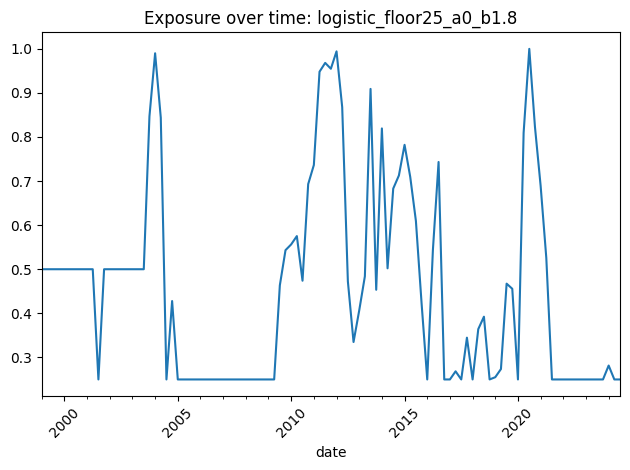

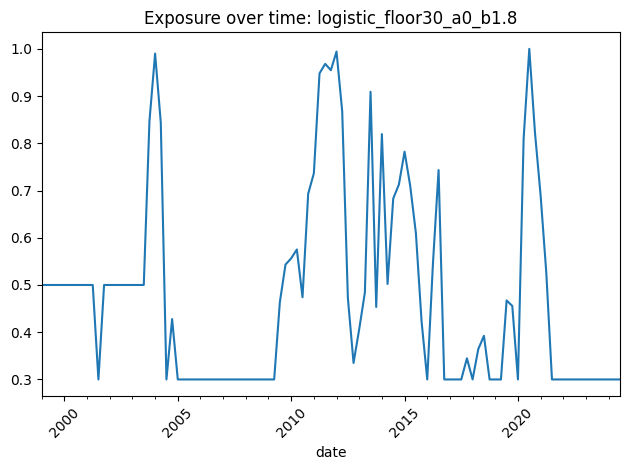

In [30]:
for f in floors:
    name = f"logistic_floor{int(f*100)}_a0_b1.8"
    s = pd.Series(
        df[f"exposure_{name}"].values,
        index=df["date"]
    )
    s.plot(title=f"Exposure over time: {name}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

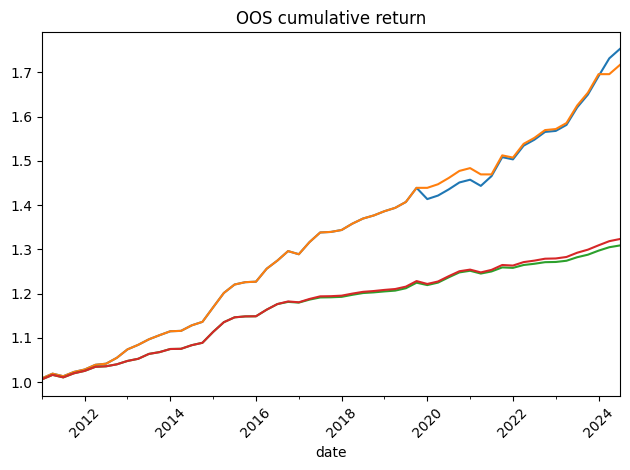

In [31]:
def cumprod_series(r):
    r = r.fillna(0)
    return (1 + r).cumprod()

oos_dates = df.loc[oos, "date"]

baseline = pd.Series(
    df.loc[oos, "strat_baseline"].values,
    index=oos_dates
)

phase2 = pd.Series(
    df.loc[oos, "strat_p2"].values,
    index=oos_dates
)

ax = cumprod_series(baseline).plot(
    title="OOS cumulative return"
)

cumprod_series(phase2).plot(ax=ax)

for f in floors:
    name = f"logistic_floor{int(f*100)}_a0_b1.8"
    strat = pd.Series(
        df.loc[oos, f"strat_{name}"].values,
        index=oos_dates
    )
    cumprod_series(strat).plot(ax=ax)

plt.xticks(rotation=45)
plt.tight_layout()

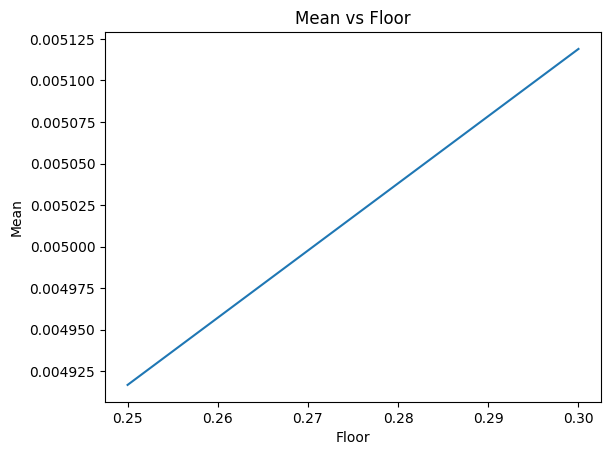

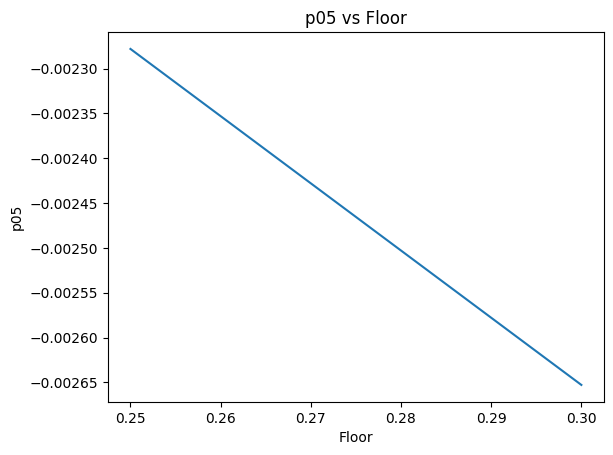

In [32]:
floor_rows = summary[summary.index.str.startswith("logistic_floor")]

floors_extracted = (
    floor_rows.index
    .str.extract(r'logistic_floor(\d+)_')[0]
    .astype(int) / 100
)

floor_means = floor_rows["mean"].values
floor_p05 = floor_rows["p05"].values

order = np.argsort(floors_extracted.values)

floors_sorted = floors_extracted.values[order]
means_sorted = floor_means[order]
p05_sorted = floor_p05[order]

plt.figure()
plt.plot(floors_sorted, means_sorted)
plt.title("Mean vs Floor")
plt.xlabel("Floor")
plt.ylabel("Mean")
plt.show()

plt.figure()
plt.plot(floors_sorted, p05_sorted)
plt.title("p05 vs Floor")
plt.xlabel("Floor")
plt.ylabel("p05")
plt.show()

In [33]:
OUT_SERIES = "outputs/phase4/series/oos_series_v42.csv"
OUT_SUMMARY = "outputs/phase4/tables/oos_summary_v42.csv"

df.to_csv(OUT_SERIES, index=False)
summary.to_csv(OUT_SUMMARY)

print("Saved v42 outputs.")

Saved v42 outputs.
